
# Naive Bayes Classification – Webinar Notebook

**Objective:**  
Demonstrate Naive Bayes concepts, assumptions, and probability behavior using visualizations.

Dataset: Diabetes Dataset  




## 1. Imports & Setup
We import required libraries for data handling, modeling, and visualization.


In [10]:

#Importing Necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.metrics import accuracy_score



## 2. Load Dataset


In [11]:
#Loading the dataset

uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])
df.head()

Saving diabetes.csv to diabetes.csv


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [16]:
#Let's observe the shape of the dataframe.
df.shape

(768, 9)


## 3. Train-Test Split


In [18]:
#Let's create numpy arrays for features and target
X = df.drop('Outcome',axis=1).values
y = df['Outcome'].values

#importing train_test_split
from sklearn.model_selection import train_test_split

#Split the dataset into train and test with stratification
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.4,random_state=42, stratify=y)


## 4. Train Gaussian Naive Bayes


In [19]:
#import Gaussian NB Classifier
from sklearn.naive_bayes import GaussianNB

#Setup a gnb classifier
model = GaussianNB()

#Fit the model
model.fit(X_train, y_train)

#Compute accuracy on the training set
print("Train Accuracy:",model.score(X_train, y_train))

#Compute accuracy on the test set
print("Test Accuracy:",model.score(X_test, y_test))

Train Accuracy: 0.782608695652174
Test Accuracy: 0.7337662337662337



## 5. Visualizing Class Probability Distributions

Gaussian Naive Bayes assumes **normal distributions** for features per class.
Below we visualize this assumption.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


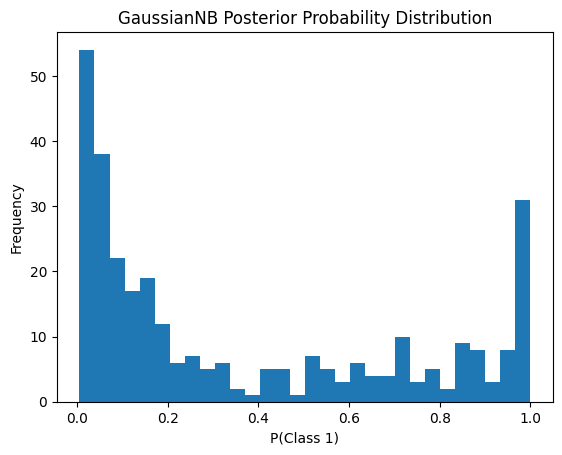

In [28]:
probs_gnb = gnb.predict_proba(X_test)
#Instead of predicting just 0 or 1, the model gives us probabilities

plt.figure()
plt.hist(probs_gnb[:,1], bins=30)
plt.xlabel("P(Class 1)")
plt.ylabel("Frequency")
plt.title("GaussianNB Posterior Probability Distribution")
plt.show()

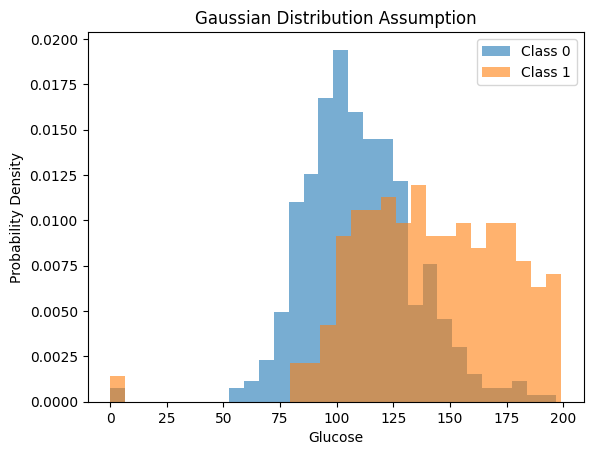

In [14]:
#We select one feature to analyze

feature = "Glucose"

plt.figure()
for label in [0, 1]:
    data = X_train[feature][y_train == label]
    plt.hist(data, bins=30, density=True, alpha=0.6, label=f"Class {label}")

plt.xlabel(feature)
plt.ylabel("Probability Density")
plt.title("Gaussian Distribution Assumption")
plt.legend()
plt.show()


### Classification report
#### Classification report is a tool used to evaluate the performance of a classification model. It provides a summary of key metrics for each class in the target variable.

In [22]:
#import classification_report

from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))


#Precision tells us how careful the model is
#Recall tells us how alert the model is.
#F1-score is the overall health score of the model for that class.
#Support : The number of actual occurrences of each class in the dataset.
#It indicates how many samples from each class are present in the test set.


              precision    recall  f1-score   support

           0       0.80      0.80      0.80       201
           1       0.62      0.62      0.62       107

    accuracy                           0.73       308
   macro avg       0.71      0.71      0.71       308
weighted avg       0.73      0.73      0.73       308



### ROC Curve
The ROC curve (Receiver Operating Characteristic curve) is a graphical representation used to evaluate the performance of a classification model, particularly in binary classification problems. It shows the tradeoff between TPR and FPR for different threshold values.

AUC (Area Under the Curve): is a single value that summarizes the overall performance of the model. A model with a higher AUC (closer to 1) indicates better performance. An AUC of 0.5 means the model has no discrimination ability (i.e., it performs randomly)

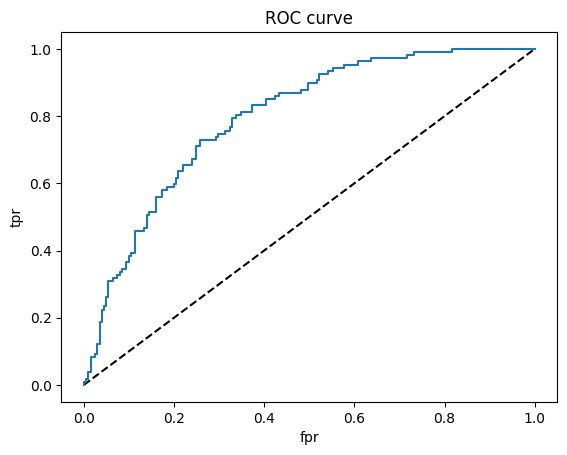

In [23]:
y_pred_proba = model.predict_proba(X_test)[:,1]

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.plot([0,1],[0,1],'k--')
plt.plot(fpr,tpr, label='GNB')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title('ROC curve')
plt.show()

In [24]:
#Area under ROC curve
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test,y_pred_proba)

np.float64(0.7960199004975124)

#### How to Interpret the ROC Curve:
Perfect Model: A curve that passes through the top-left corner (FPR = 0, TPR = 1) represents a perfect classifier.

Random Model: A diagonal line from the bottom-left to the top-right (FPR = TPR) represents random guessing. A model performing as random guessing would have an AUC of 0.5.

Better Model: A curve that is above the diagonal and closer to the top-left corner indicates better model performance.

## 6. Multinomial Naive Bayes

In [31]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

mnb = MultinomialNB()
mnb.fit(X_train_m, y_train_m)

y_pred_mnb = mnb.predict(X_test_m)
print("MultinomialNB Accuracy:", accuracy_score(y_test_m, y_pred_mnb))

MultinomialNB Accuracy: 0.6493506493506493


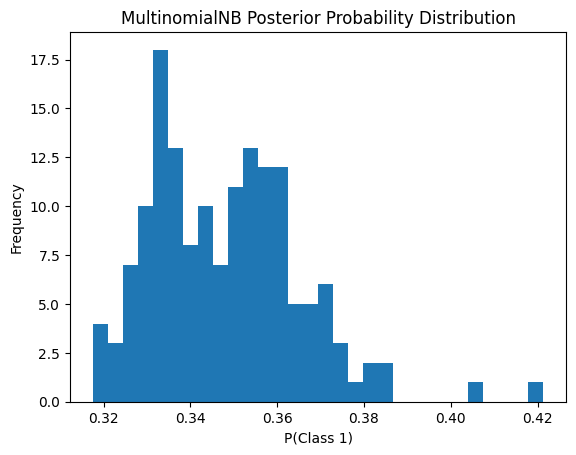

In [32]:
probs_mnb = mnb.predict_proba(X_test_m)

plt.figure()
plt.hist(probs_mnb[:,1], bins=30)
plt.xlabel("P(Class 1)")
plt.ylabel("Frequency")
plt.title("MultinomialNB Posterior Probability Distribution")
plt.show()

## 7. Bernoulli Naive Bayes

In [33]:
X_binary = (X > X.mean()).astype(int)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_binary, y, test_size=0.2, random_state=42, stratify=y
)

bnb = BernoulliNB()
bnb.fit(X_train_b, y_train_b)

y_pred_bnb = bnb.predict(X_test_b)
print("BernoulliNB Accuracy:", accuracy_score(y_test_b, y_pred_bnb))

BernoulliNB Accuracy: 0.5844155844155844


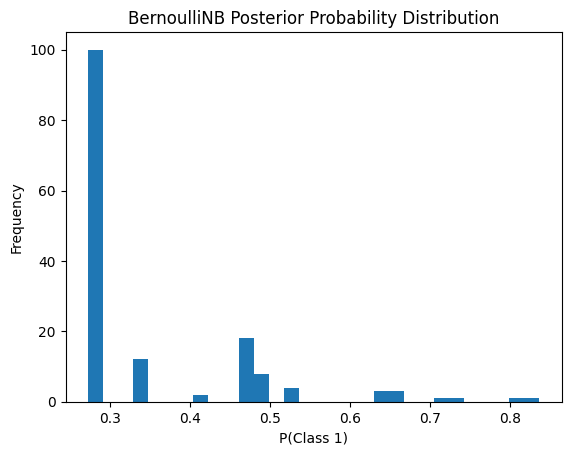

In [34]:
probs_bnb = bnb.predict_proba(X_test_b)

plt.figure()
plt.hist(probs_bnb[:,1], bins=30)
plt.xlabel("P(Class 1)")
plt.ylabel("Frequency")
plt.title("BernoulliNB Posterior Probability Distribution")
plt.show()

##Model Comparison

In [35]:
results = pd.DataFrame({
    "Model": ["GaussianNB", "MultinomialNB", "BernoulliNB"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test_m, y_pred_mnb),
        accuracy_score(y_test_b, y_pred_bnb)
    ]
})

results

,Model,Accuracy
0,GaussianNB,0.733766
1,MultinomialNB,0.649351
2,BernoulliNB,0.584416


## 8. Key Learning Points

| Feature / Aspect                  | **GaussianNB (GNB)**               | **MultinomialNB (MNB)**       | **BernoulliNB (BNB)**           |
| --------------------------------- | ---------------------------------- | ----------------------------- | ------------------------------- |
| **Data Type Assumed**             | Continuous numeric data            | Discrete count data           | Binary (0/1) data               |
| **Underlying Distribution**       | Gaussian (Normal)                  | Multinomial                   | Bernoulli                       |
| **Feature Values**                | Real-valued (e.g., glucose, BMI)   | Counts (e.g., word frequency) | Presence / absence              |
| **Probability Shape (Observed)**  | Smooth, wide spread (0 → 1)        | Narrow, clustered             | Spiky, discrete                 |
| **Model Confidence**              | High                               | Low                           | Medium–Low                      |
| **Class Separation**              | Clear separation                   | Weak separation               | Partial separation              |
| **Sensitivity to Scaling**        | Moderate (scaling helps)           | Should NOT scale              | Requires binarization           |
| **Handles Continuous Data Well?** | ✅ Yes                              | ❌ No                          | ❌ No                            |
| **Handles Text Data Well?**       | ❌ No                               | ✅ Yes                         | ✅ Yes                           |
| **Computational Speed**           | Very fast                          | Very fast                     | Very fast                       |
| **Interpretability**              | Easy                               | Easy                          | Easy                            |
| **Best Use Cases**                | Medical data, sensor data, finance | Text classification, NLP      | Spam detection, binary features |
| **Performance on This Dataset**   | ⭐ Best                             | ⚠️ Poor                       | ⚠️ Poor                         |
